In [1]:
import os
import numpy as np
import librosa
import soundfile as sf
import scipy.signal as signal
import scipy.io.wavfile as wav
from scipy.fftpack import fft, ifft
from scipy.special import expi

input_base_dir = "Noisy_EmoDB"
output_paper_dir = "Enhanced_EmoDB_PAPER"
output_mmse_dir = "Enhanced_EmoDB_MMSE"

def calculate_gwf(audio, sr):
    analytic_signal = signal.hilbert(audio)
    envelope = np.abs(analytic_signal)
    nyquist = sr / 2
    b, a = signal.butter(2, 50 / nyquist, btype='low')
    gwf = signal.filtfilt(b, a, envelope)
    return gwf / (np.max(gwf) + 1e-6)

def lp_analysis_and_fwf(audio, sr, order=16):
    audio_safe = audio + np.random.normal(0, 1e-8, len(audio))
    a_coeffs = librosa.lpc(audio_safe, order=order)
    residual = signal.lfilter(a_coeffs, [1.0], audio_safe)
    analytic_residual = signal.hilbert(residual)
    res_envelope = np.abs(analytic_residual)
    nyquist = sr / 2
    b, a = signal.butter(2, 500 / nyquist, btype='low')
    fwf = signal.filtfilt(b, a, res_envelope)
    return a_coeffs, residual, fwf / (np.max(fwf) + 1e-6)

def spectral_subtraction_relaxed(audio):
    S = librosa.stft(audio, n_fft=512, hop_length=256)
    mag = np.abs(S)
    phase = np.exp(1.j * np.angle(S))
    noise_mag = np.mean(mag[:, :10], axis=1, keepdims=True)
    mag_clean = np.maximum(mag - 1.2 * noise_mag, 0.05 * noise_mag)
    S_clean = mag_clean * phase
    return librosa.istft(S_clean, hop_length=256)

def apply_paper_ctsp(audio, sr=16000, order=16):
    gwf = calculate_gwf(audio, sr)
    a_coeffs, residual, fwf = lp_analysis_and_fwf(audio, sr, order)
    twf = gwf * fwf
    enhanced_residual = residual * twf
    temporally_enhanced_audio = signal.lfilter([1.0], a_coeffs, enhanced_residual)
    min_len = min(len(audio), len(temporally_enhanced_audio))
    temporally_enhanced_audio = temporally_enhanced_audio[:min_len]
    final_audio = spectral_subtraction_relaxed(temporally_enhanced_audio)
    if np.max(np.abs(final_audio)) > 0:
        final_audio = final_audio / np.max(np.abs(final_audio))
    return final_audio

def stft(signal, frame_len, frame_shift, window):
    frames = []
    for i in range(0, len(signal) - frame_len, frame_shift):
        frame = signal[i:i+frame_len] * window
        frames.append(fft(frame))
    return np.array(frames)

def istft(frames, frame_len, frame_shift, window):
    signal_len = frame_shift * (len(frames) + 1)
    output = np.zeros(signal_len)
    for i, frame in enumerate(frames):
        time_frame = np.real(ifft(frame)) * window
        output[i*frame_shift:i*frame_shift+frame_len] += time_frame
    return output

def apply_mmse(noisy, rate_noisy):
    noisy = noisy.astype(np.float32) / np.max(np.abs(noisy))
    frame_len = int(0.020 * rate_noisy)
    frame_shift = int(0.010 * rate_noisy)
    window = np.hamming(frame_len)
    alpha, gamma_0, beta = 0.98, 4.6, 0.9  

    noisy_stft = stft(noisy, frame_len, frame_shift, window)
    noise_psd = np.mean(np.abs(noisy_stft[:5])**2, axis=0)
    prev_gain = np.ones_like(noise_psd)
    enhanced_stft = []

    for i in range(len(noisy_stft)):
        Y = noisy_stft[i]
        noisy_psd = np.abs(Y)**2
        gamma_k = noisy_psd / (noise_psd + 1e-10)
        xi_k = beta * (prev_gain**2) * noisy_psd / (noise_psd + 1e-10) + (1 - beta) * np.maximum(gamma_k - 1, 0)
        gain = (xi_k / (1 + xi_k)) * np.exp(0.5 * expi(-xi_k))
        prev_gain = gain
        X = gain * Y
        enhanced_stft.append(X)
        update_mask = gamma_k < gamma_0
        noise_psd[update_mask] = alpha * noise_psd[update_mask] + (1 - alpha) * noisy_psd[update_mask]
        
    enhanced = istft(enhanced_stft, frame_len, frame_shift, window)
    if np.max(np.abs(enhanced)) > 0:
        enhanced = enhanced / np.max(np.abs(enhanced))
    return enhanced

noisy_folders = [f for f in os.listdir(input_base_dir) if os.path.isdir(os.path.join(input_base_dir, f))]

for folder in noisy_folders:
    os.makedirs(os.path.join(output_paper_dir, folder), exist_ok=True)
    os.makedirs(os.path.join(output_mmse_dir, folder), exist_ok=True)

print("Starting Dual Enhancement Processing...")

for folder_idx, folder_name in enumerate(noisy_folders):
    print(f"Processing folder: {folder_name}")
    
    input_folder_path = os.path.join(input_base_dir, folder_name)
    out_paper_path = os.path.join(output_paper_dir, folder_name)
    out_mmse_path = os.path.join(output_mmse_dir, folder_name)
    
    audio_files = [f for f in os.listdir(input_folder_path) if f.endswith('.wav')]
    
    for filename in audio_files:
        in_path = os.path.join(input_folder_path, filename)
        
        noisy_lib, sr_lib = librosa.load(in_path, sr=16000)
        enhanced_paper = apply_paper_ctsp(noisy_lib, sr_lib)
        sf.write(os.path.join(out_paper_path, filename), enhanced_paper, sr_lib)
        
        rate_wav, noisy_wav = wav.read(in_path)
        enhanced_mmse = apply_mmse(noisy_wav, rate_wav)
        wav.write(os.path.join(out_mmse_path, filename), rate_wav, (enhanced_mmse * 32767).astype(np.int16))
        
    print(f"Finished {folder_name}")

print("Dual Enhancement Complete.")

Starting Dual Enhancement Processing...
Processing folder: Cafe_-10dB


C:\Users\Affan\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.12_qbz5n2kfra8p0\LocalCache\local-packages\Python312\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Finished Cafe_-10dB
Processing folder: Cafe_-5dB
Finished Cafe_-5dB
Processing folder: Cafe_0dB
Finished Cafe_0dB
Processing folder: Cafe_10dB
Finished Cafe_10dB
Processing folder: Cafe_15dB
Finished Cafe_15dB
Processing folder: Cafe_5dB
Finished Cafe_5dB
Processing folder: Street_-10dB
Finished Street_-10dB
Processing folder: Street_-5dB
Finished Street_-5dB
Processing folder: Street_0dB
Finished Street_0dB
Processing folder: Street_10dB
Finished Street_10dB
Processing folder: Street_15dB
Finished Street_15dB
Processing folder: Street_5dB
Finished Street_5dB
Processing folder: White_-10dB
Finished White_-10dB
Processing folder: White_-5dB
Finished White_-5dB
Processing folder: White_0dB
Finished White_0dB
Processing folder: White_10dB
Finished White_10dB
Processing folder: White_15dB
Finished White_15dB
Processing folder: White_5dB
Finished White_5dB
Dual Enhancement Complete.


Generating Waveform Comparisons for both algorithms...
Selected example file: 03a01Wa.wav
Processing Environment: Cafe_0dB
Plotting Paper CTSP for Cafe_0dB


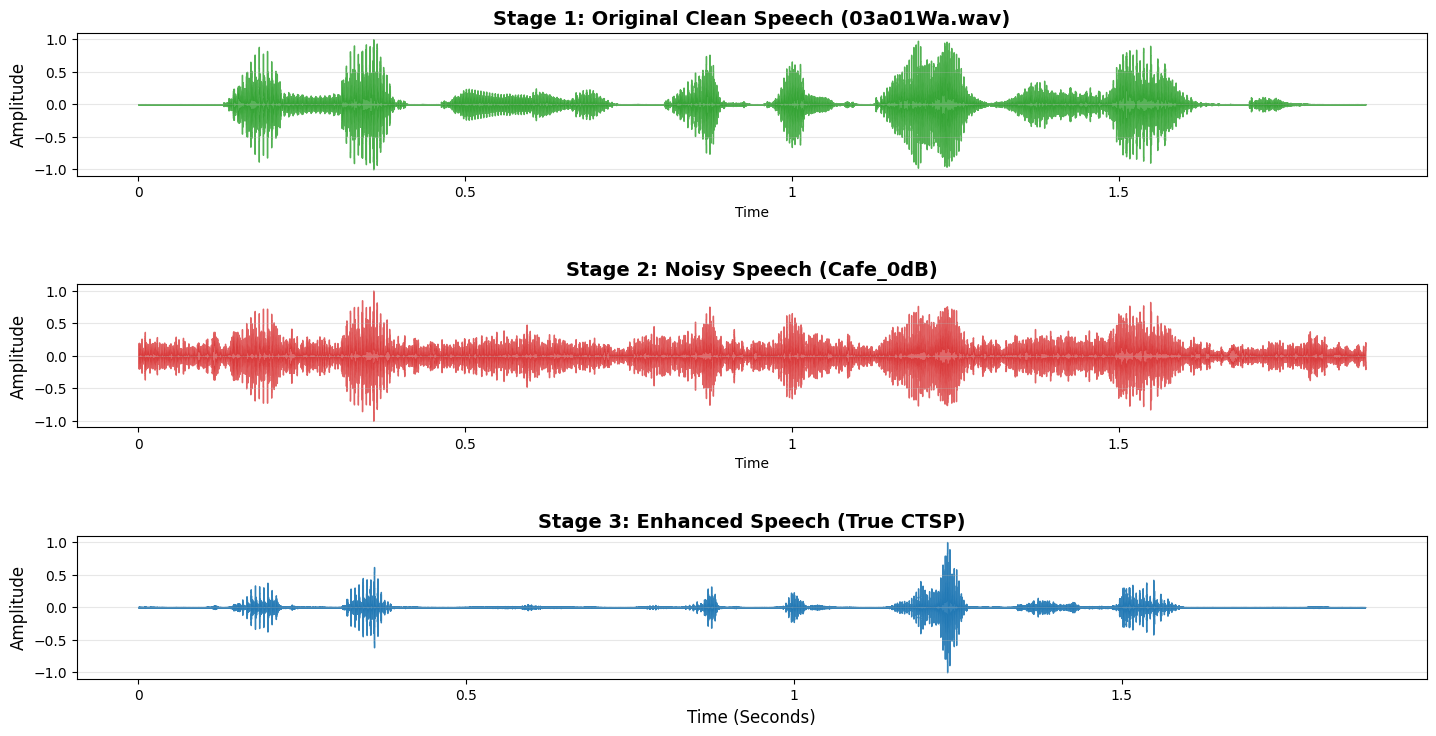

Paper CTSP proof saved to: images\Visualization_1A_CTSP_Cafe_0dB.png
Plotting Ephraim-Malah MMSE for Cafe_0dB


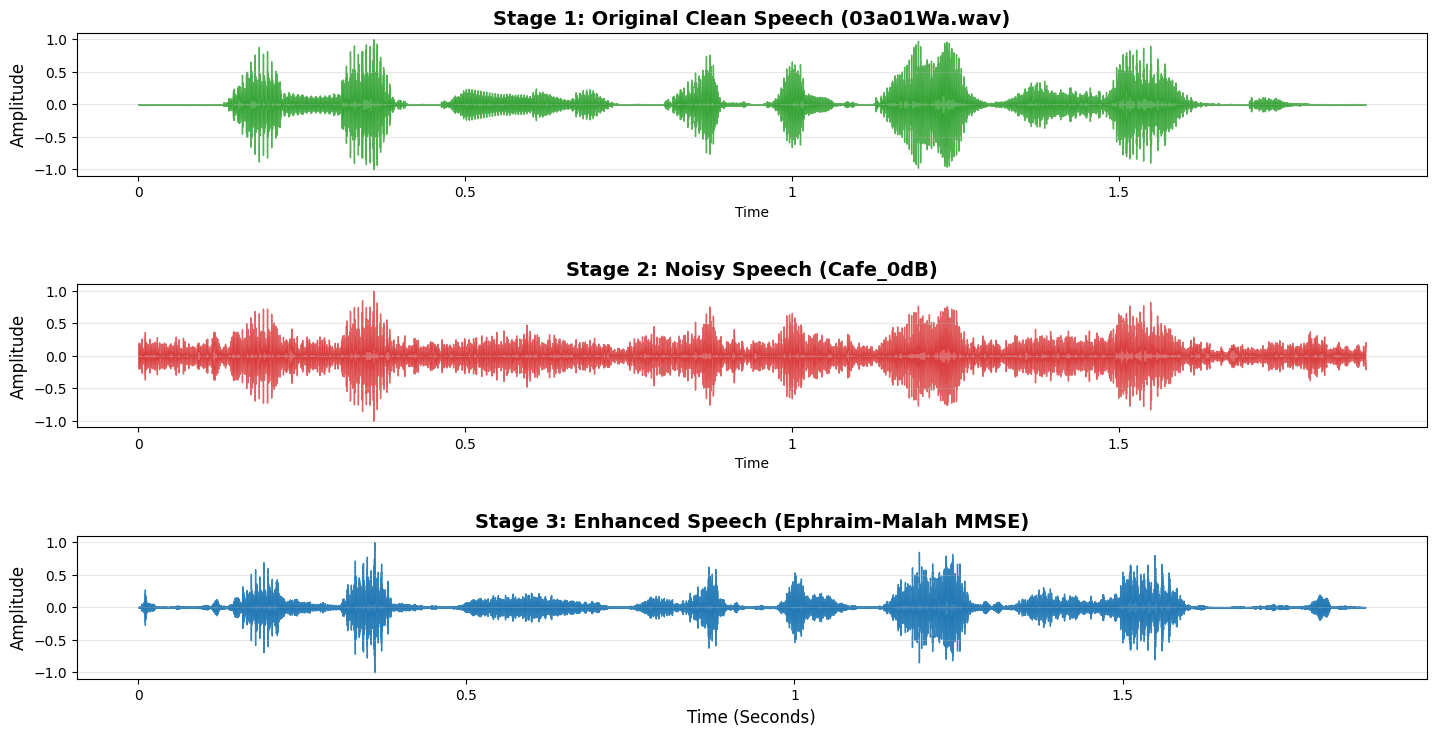

Ephraim-Malah MMSE proof saved to: images\Visualization_1B_MMSE_Cafe_0dB.png
Processing Environment: White_0dB
Plotting Paper CTSP for White_0dB


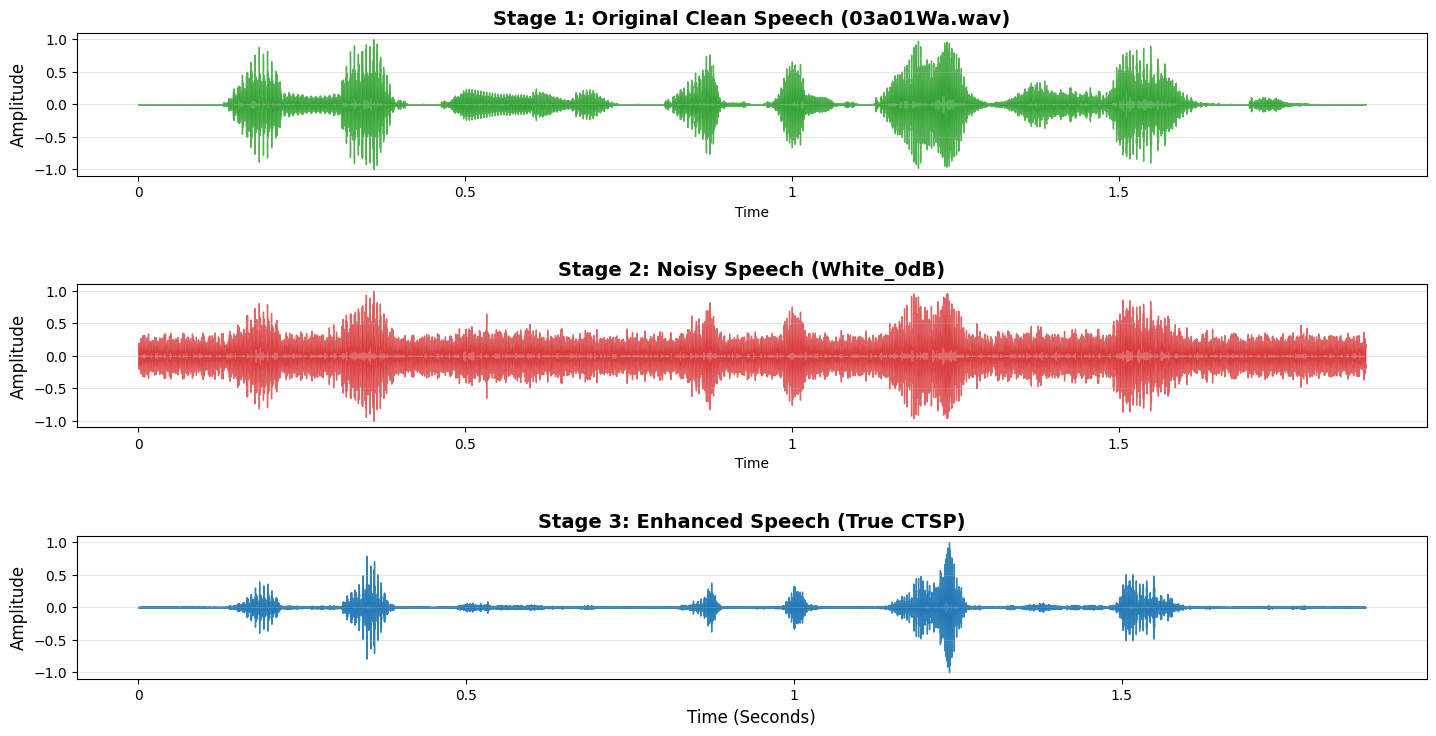

Paper CTSP proof saved to: images\Visualization_1A_CTSP_White_0dB.png
Plotting Ephraim-Malah MMSE for White_0dB


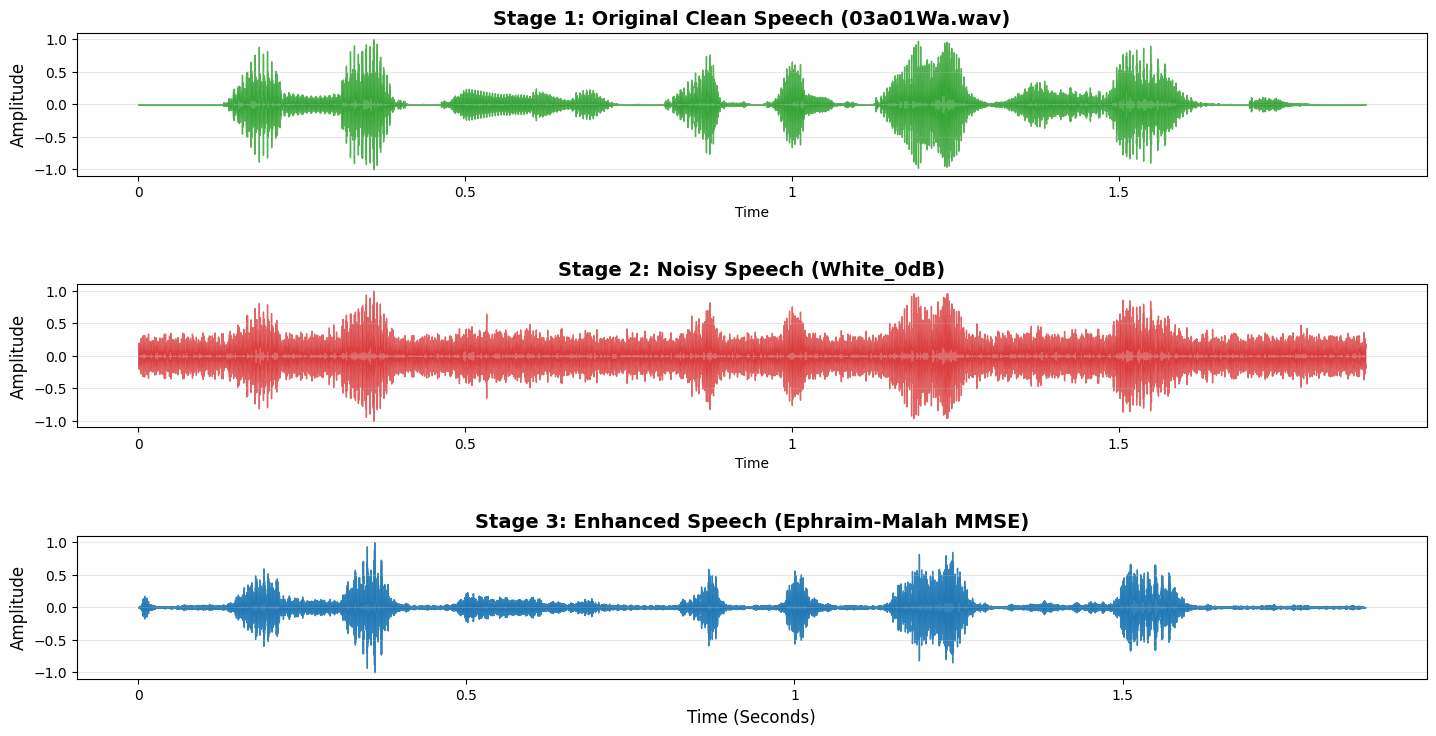

Ephraim-Malah MMSE proof saved to: images\Visualization_1B_MMSE_White_0dB.png
Processing Environment: Cafe_15dB
Plotting Paper CTSP for Cafe_15dB


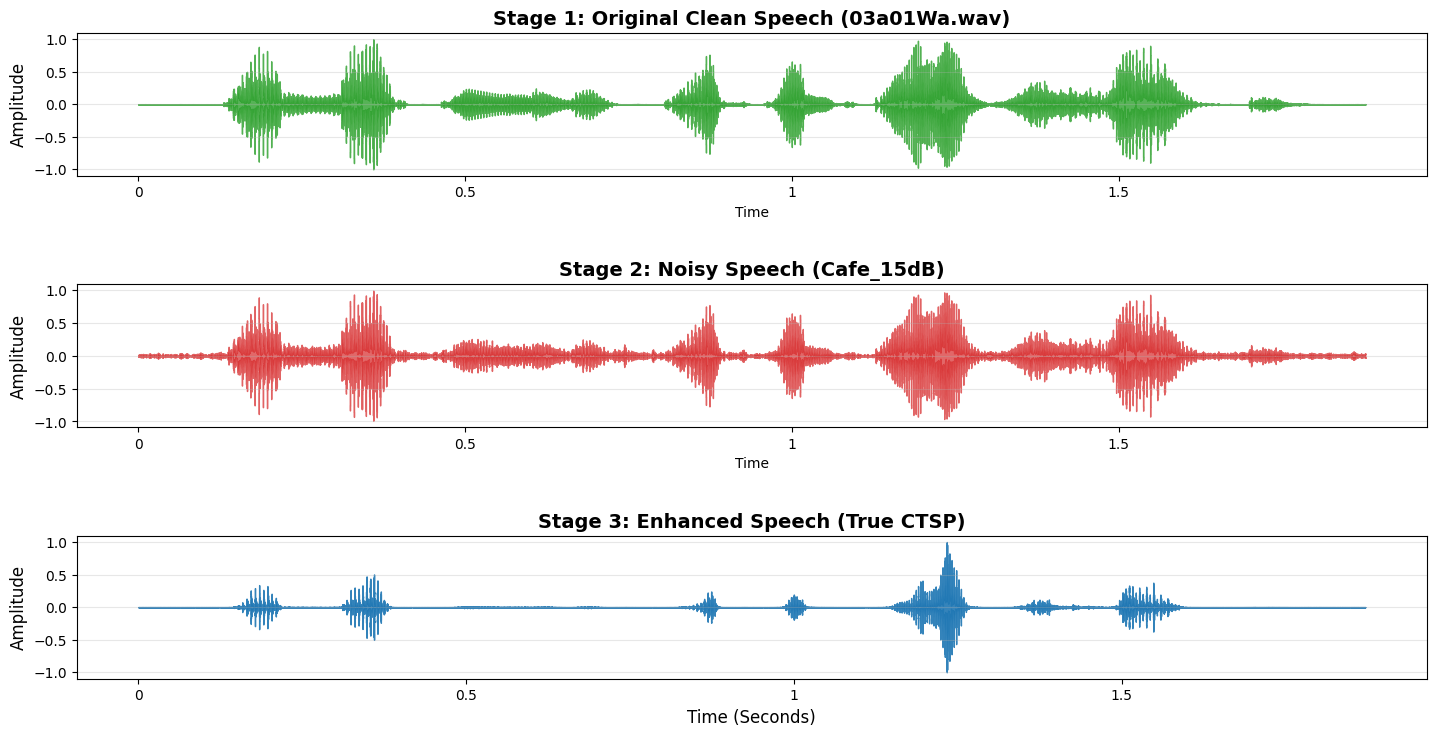

Paper CTSP proof saved to: images\Visualization_1A_CTSP_Cafe_15dB.png
Plotting Ephraim-Malah MMSE for Cafe_15dB


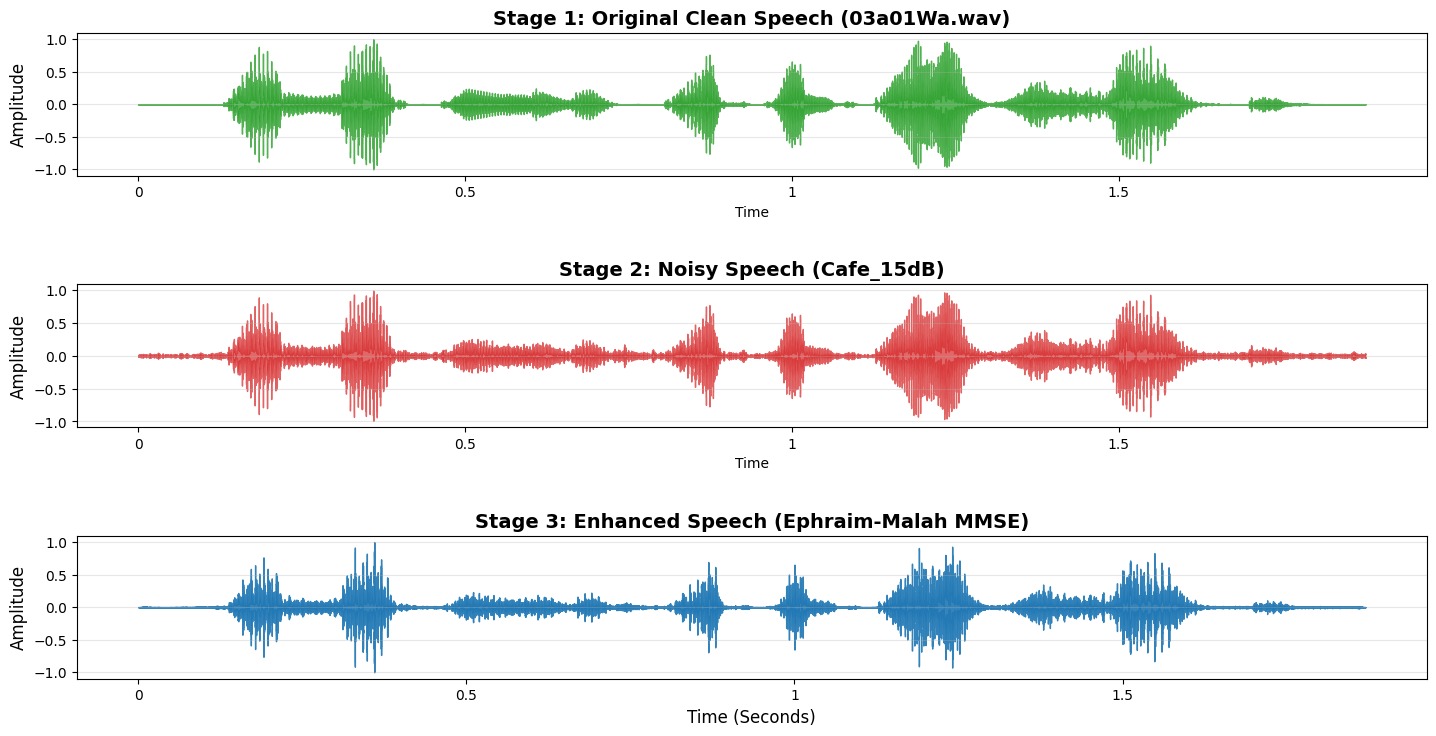

Ephraim-Malah MMSE proof saved to: images\Visualization_1B_MMSE_Cafe_15dB.png
Processing Environment: White_15dB
Plotting Paper CTSP for White_15dB


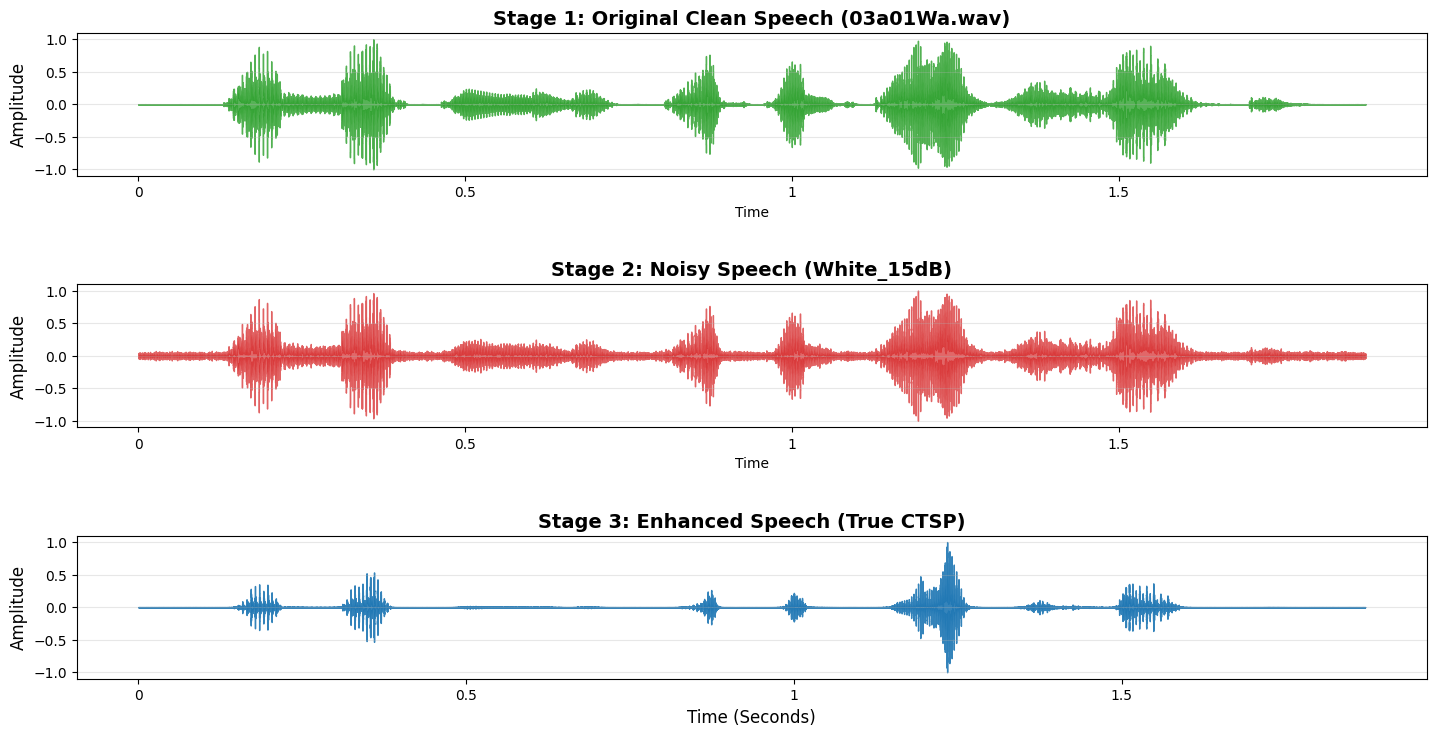

Paper CTSP proof saved to: images\Visualization_1A_CTSP_White_15dB.png
Plotting Ephraim-Malah MMSE for White_15dB


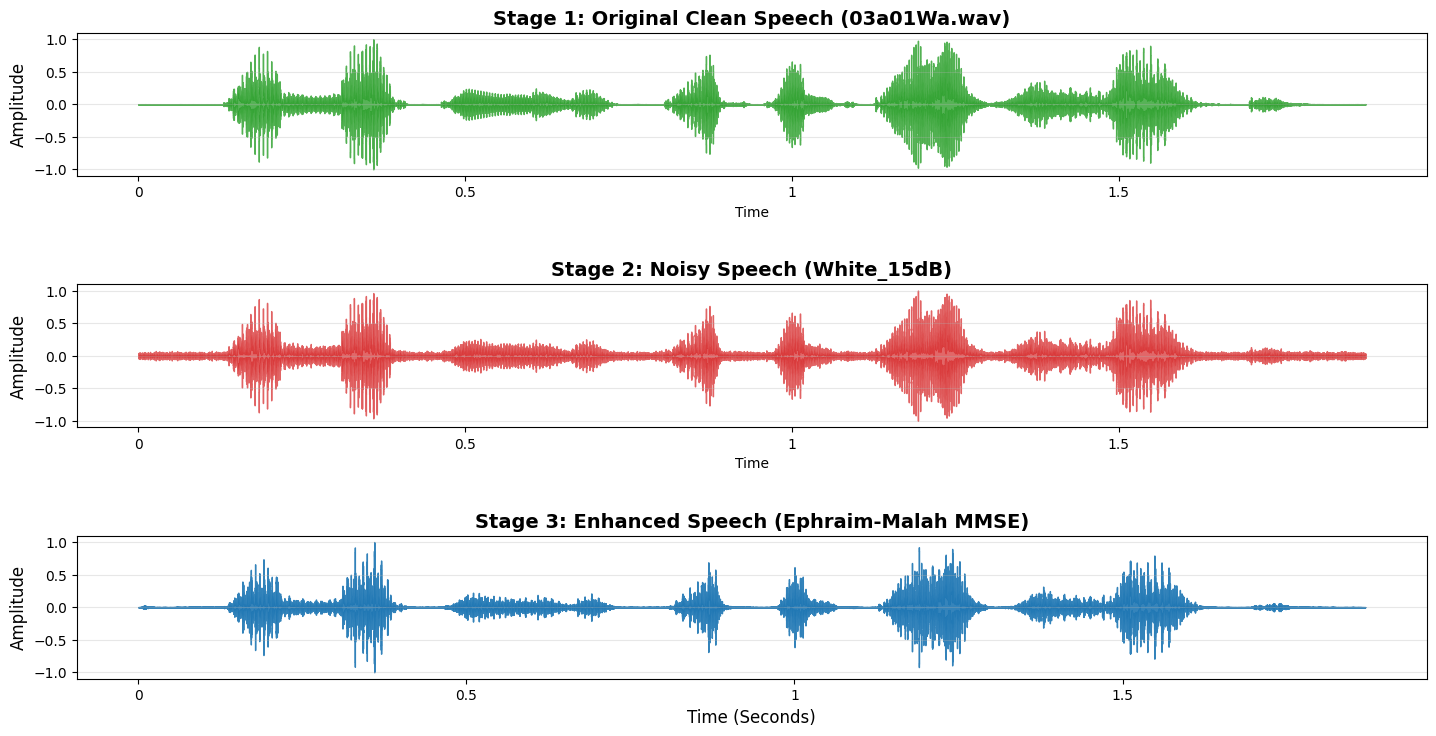

Ephraim-Malah MMSE proof saved to: images\Visualization_1B_MMSE_White_15dB.png


In [3]:
import os
import librosa
import librosa.display
import matplotlib.pyplot as plt

print("Generating Waveform Comparisons for both algorithms...")

original_db_dir = r"E:\SSP-Project-V1\wav" 
noisy_base_dir = "Noisy_EmoDB"
enhanced_paper_dir = "Enhanced_EmoDB_PAPER"
enhanced_mmse_dir = "Enhanced_EmoDB_MMSE"
img_dir = "images"
os.makedirs(img_dir, exist_ok=True)

test_envs = ["Cafe_0dB", "White_0dB", "Cafe_15dB", "White_15dB"] 
emotion_target = 'W' 

all_files = [f for f in os.listdir(original_db_dir) if f.endswith('.wav')]
target_files = [f for f in all_files if len(f) > 5 and f[5] == emotion_target]

if not target_files:
    print(f"Error: Could not find any emotion {emotion_target} files in the directory.")
else:
    filename_example = target_files[0] 
    print(f"Selected example file: {filename_example}")

    clean_orig_path = os.path.join(original_db_dir, filename_example)
    
    y_orig, sr = librosa.load(clean_orig_path, sr=16000)

    for env in test_envs:
        print(f"Processing Environment: {env}")
        noisy_path = os.path.join(noisy_base_dir, env, filename_example)

        algorithms = {
            "Paper CTSP": {
                "dir": enhanced_paper_dir,
                "title": "Stage 3: Enhanced Speech (True CTSP)",
                "filename_prefix": "Visualization_1A_CTSP"
            },
            "Ephraim-Malah MMSE": {
                "dir": enhanced_mmse_dir,
                "title": "Stage 3: Enhanced Speech (Ephraim-Malah MMSE)",
                "filename_prefix": "Visualization_1B_MMSE"
            }
        }

        try:
            y_noisy, _ = librosa.load(noisy_path, sr=16000)

            for algo_name, algo_data in algorithms.items():
                print(f"Plotting {algo_name} for {env}")
                enhanced_path = os.path.join(algo_data["dir"], env, filename_example)
                y_enhanced, _ = librosa.load(enhanced_path, sr=16000)

                plt.figure(figsize=(15, 8))

                plt.subplot(3, 1, 1)
                librosa.display.waveshow(y_orig, sr=sr, color='#2ca02c', alpha=0.8)
                plt.title(f"Stage 1: Original Clean Speech ({filename_example})", fontsize=14, fontweight='bold')
                plt.ylabel("Amplitude", fontsize=12)
                plt.grid(True, axis='y', alpha=0.3)

                plt.subplot(3, 1, 2)
                librosa.display.waveshow(y_noisy, sr=sr, color='#d62728', alpha=0.7)
                plt.title(f"Stage 2: Noisy Speech ({env})", fontsize=14, fontweight='bold')
                plt.ylabel("Amplitude", fontsize=12)
                plt.grid(True, axis='y', alpha=0.3)

                plt.subplot(3, 1, 3)
                librosa.display.waveshow(y_enhanced, sr=sr, color='#1f77b4', alpha=0.9)
                plt.title(algo_data["title"], fontsize=14, fontweight='bold')
                plt.ylabel("Amplitude", fontsize=12)
                plt.xlabel("Time (Seconds)", fontsize=12)
                plt.grid(True, axis='y', alpha=0.3)

                plt.tight_layout(pad=3.0)
                
                save_path = os.path.join(img_dir, f'{algo_data["filename_prefix"]}_{env}.png')
                plt.savefig(save_path, dpi=300, bbox_inches='tight')
                plt.show()
                print(f"{algo_name} proof saved to: {save_path}")

        except FileNotFoundError as e:
            print(f"Error loading audio files: {e}. Please ensure the Enhancement script has fully processed {env} first.")